#  MC Maze: Neural Decoder Metamer Discovery

This notebook demonstrates how to use the **Metamer Finder** tool to analyze neural decoders using real-world datasets. 

### Highlights
- **Dataset**: NLB-Tools MC_Maze (Monkey Motor Cortex during reaching).
- **Model**: Neural Data Transformer (NDT) Foundation Model.
- **Technique**: Gradient-based optimization with custom biological and adversarial constraints.

## 1. Setup & Path Management
We ensure the engine is discoverable and import necessary libraries.

In [1]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional, List

from nlb_tools.nwb_interface import NWBDataset
from nlb_tools.make_tensors import make_train_input_tensors

# Locate project root automatically
def find_project_root(target='metamer_finder'):
    curr = os.path.abspath('')
    while not os.path.exists(os.path.join(curr, target)):
        parent = os.path.dirname(curr)
        if parent == curr: raise FileNotFoundError(f"Could not find {target} root.")
        curr = parent
    return curr

root_dir = find_project_root()
if root_dir not in sys.path: sys.path.append(root_dir)

from metamer_finder import MetamerOptimizer, FeatureExtractor

print(f"✅ Metamer Finder engine loaded from: {root_dir}")

✅ Metamer Finder engine loaded from: c:\Users\brayk\OneDrive\Codes\Metamers\MetamerFinder


## 2. Load MC Maze Dataset
We load the official Neural Latents Benchmark (NLB) MC_Maze dataset.

In [2]:
dataset_path = os.path.join(root_dir, 'experiments', 'data', 'mc_maze', '000128', 'sub-Jenkins', 'sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb')
dataset = NWBDataset(dataset_path)

# Preprocessing and resampling to 20ms bins
try:
    dataset.resample(20)
except ValueError as e:
    if "Inferred frequency" in str(e) or "passed frequency" in str(e):
        dataset.bin_width = 20
    else:
        raise e

dataset.data = dataset.data.sort_index()

train_dict = make_train_input_tensors(
    dataset, 
    dataset_name='mc_maze', 
    trial_split='train', 
    save_file=False,
    include_behavior=True
)

full_spikes = np.concatenate([train_dict['train_spikes_heldin'], train_dict['train_spikes_heldout']], axis=-1)
real_spikes = torch.tensor(full_spikes, dtype=torch.float32)
real_kinematics = torch.tensor(train_dict['train_behavior'], dtype=torch.float32)

print(f"Loaded {real_spikes.shape[0]} trials.")
print(f"Spike Shape: {real_spikes.shape} | Kinematics Shape: {real_kinematics.shape}")

Loaded 1721 trials.
Spike Shape: torch.Size([1721, 35, 182]) | Kinematics Shape: torch.Size([1721, 35, 2])


## 3. Initialize NDT Foundation Model
We load the Neural Data Transformer and wrap it in an inference adapter.

In [3]:
ndt_repo_path = os.path.join(root_dir, 'experiments', 'neural-data-transformers')
if ndt_repo_path not in sys.path: sys.path.append(ndt_repo_path)

from src.model import NeuralDataTransformer
from src.config.default import get_config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = get_config(os.path.join(ndt_repo_path, "configs", "mc_maze.yaml"))

pretrained_decoder = (
    config=config.MODEL,
    trial_length=real_spikes.shape[1],
    num_neurons=real_spikes.shape[2],
    device=device,
    max_spikes=int(real_spikes.max().item()) + 1
)

pretrained_decoder.eval().to(device)

class NDTInferenceAdapter(nn.Module):
    def __init__(self, foundation_model):
        super().__init__()
        self.base_model = foundation_model
    def forward(self, x):
        loss, pred_rates, _, _ = self.base_model(x, mask_labels=x, passthrough=True, return_outputs=True)
        return pred_rates

adapted_decoder = NDTInferenceAdapter(pretrained_decoder)
print("✅ NDT Model initialized and adapted.")

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (835234529.py, line 11)

In [168]:
importlib.reload(inspect_model)
import inspect_model

In [171]:
from inspect_model import analyze_skip_connections
analyze_skip_connections(adapted_decoder)


Reason: triu is not in list


{}

In [20]:
for name, module in pretrained_decoder.named_modules():
    if name: # Skip the empty root module
        print(name)

embedder
pos_encoder
pos_encoder.dropout
pos_encoder.pos_embedding
transformer_encoder
transformer_encoder.layers
transformer_encoder.layers.0
transformer_encoder.layers.0.self_attn
transformer_encoder.layers.0.self_attn.out_proj
transformer_encoder.layers.0.linear1
transformer_encoder.layers.0.dropout
transformer_encoder.layers.0.linear2
transformer_encoder.layers.0.norm1
transformer_encoder.layers.0.norm2
transformer_encoder.layers.0.dropout1
transformer_encoder.layers.0.dropout2
transformer_encoder.layers.1
transformer_encoder.layers.1.self_attn
transformer_encoder.layers.1.self_attn.out_proj
transformer_encoder.layers.1.linear1
transformer_encoder.layers.1.dropout
transformer_encoder.layers.1.linear2
transformer_encoder.layers.1.norm1
transformer_encoder.layers.1.norm2
transformer_encoder.layers.1.dropout1
transformer_encoder.layers.1.dropout2
transformer_encoder.layers.2
transformer_encoder.layers.2.self_attn
transformer_encoder.layers.2.self_attn.out_proj
transformer_encoder.laye

In [11]:
print(pretrained_decoder)

NeuralDataTransformer(
  (embedder): Identity()
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
    (pos_embedding): Embedding(35, 182)
  )
  (transformer_encoder): TransformerEncoderWithHooks(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayerWithHooks(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=182, out_features=182, bias=True)
        )
        (linear1): Linear(in_features=182, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=182, bias=True)
        (norm1): LayerNorm((182,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((182,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((182,), eps=1e-05, elementwise_affine=True)
  )
  (rate_dropout): Dropout

## 4. Custom Loss Hooks and Projection
We define adversarial and biological constraints to guide the optimization.

In [109]:
multi_extractor = FeatureExtractor(adapted_decoder, target_layers=[
    "base_model.decoder" 
])
trial_idx = 42 
target_spike_train = real_spikes[trial_idx:trial_idx+1].to(device)
with torch.no_grad():
    target_multi_features = multi_extractor(target_spike_train)

In [110]:
def adversarial_loss_hook(synthetic_spikes, synthetic_features, target_features):
    repulsion_loss = torch.nn.functional.cosine_similarity(
        synthetic_spikes, target_spike_train, dim=-1
    ).mean().abs() * 0.5
    return repulsion_loss

def biological_firing_penalty(spikes, spike_features, target_features):
    l2 = torch.sum(spikes ** 2) * 0.001
    smoothness = torch.sum((spikes[:, 1:] - spikes[:, :-1]) ** 2) * 0.0001
    return l2 + smoothness

def biological_projection(tensor):
    # Enforce non-negativity and a max spike limit in-place
    tensor.data.clamp_(min=0.0, max=10)

## 5. Metamer Generation
We optimize a synthetic pattern to match the model's bottleneck activations.

In [111]:
metamer_optimizer = MetamerOptimizer(
    extractor=multi_extractor,
    target_features=target_multi_features,
    lr=0.02,
    max_iterations=1_000, 
    custom_loss_hook=adversarial_loss_hook,
    projection_fn=biological_projection,
)

start = torch.randn_like(target_spike_train).abs() * 0.5


optimized_metamer = metamer_optimizer.generate(starting_image=start)

print("✅ Metamer generation complete.")

Optimizing (mse): 100%|██████████| 1000/1000 [00:37<00:00, 26.40it/s, loss=0.161304]

✅ Metamer generation complete.


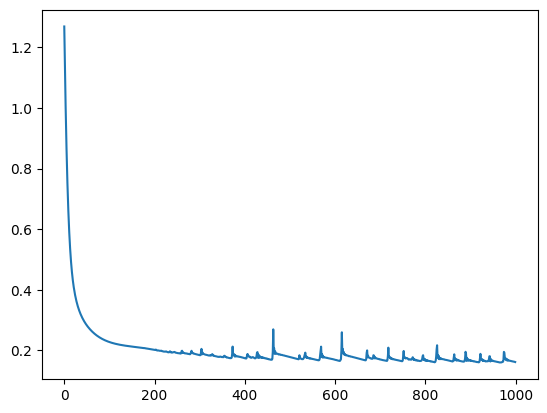

In [112]:
plt.plot(metamer_optimizer.loss_history)

## 6. Analysis & Visualization
We compare the biological target with the synthetic metamer.

In [113]:
print(torch.min(optimized_metamer), torch.max(optimized_metamer))

tensor(0.) tensor(1.6904)


Average Positional Error: 0.001 units


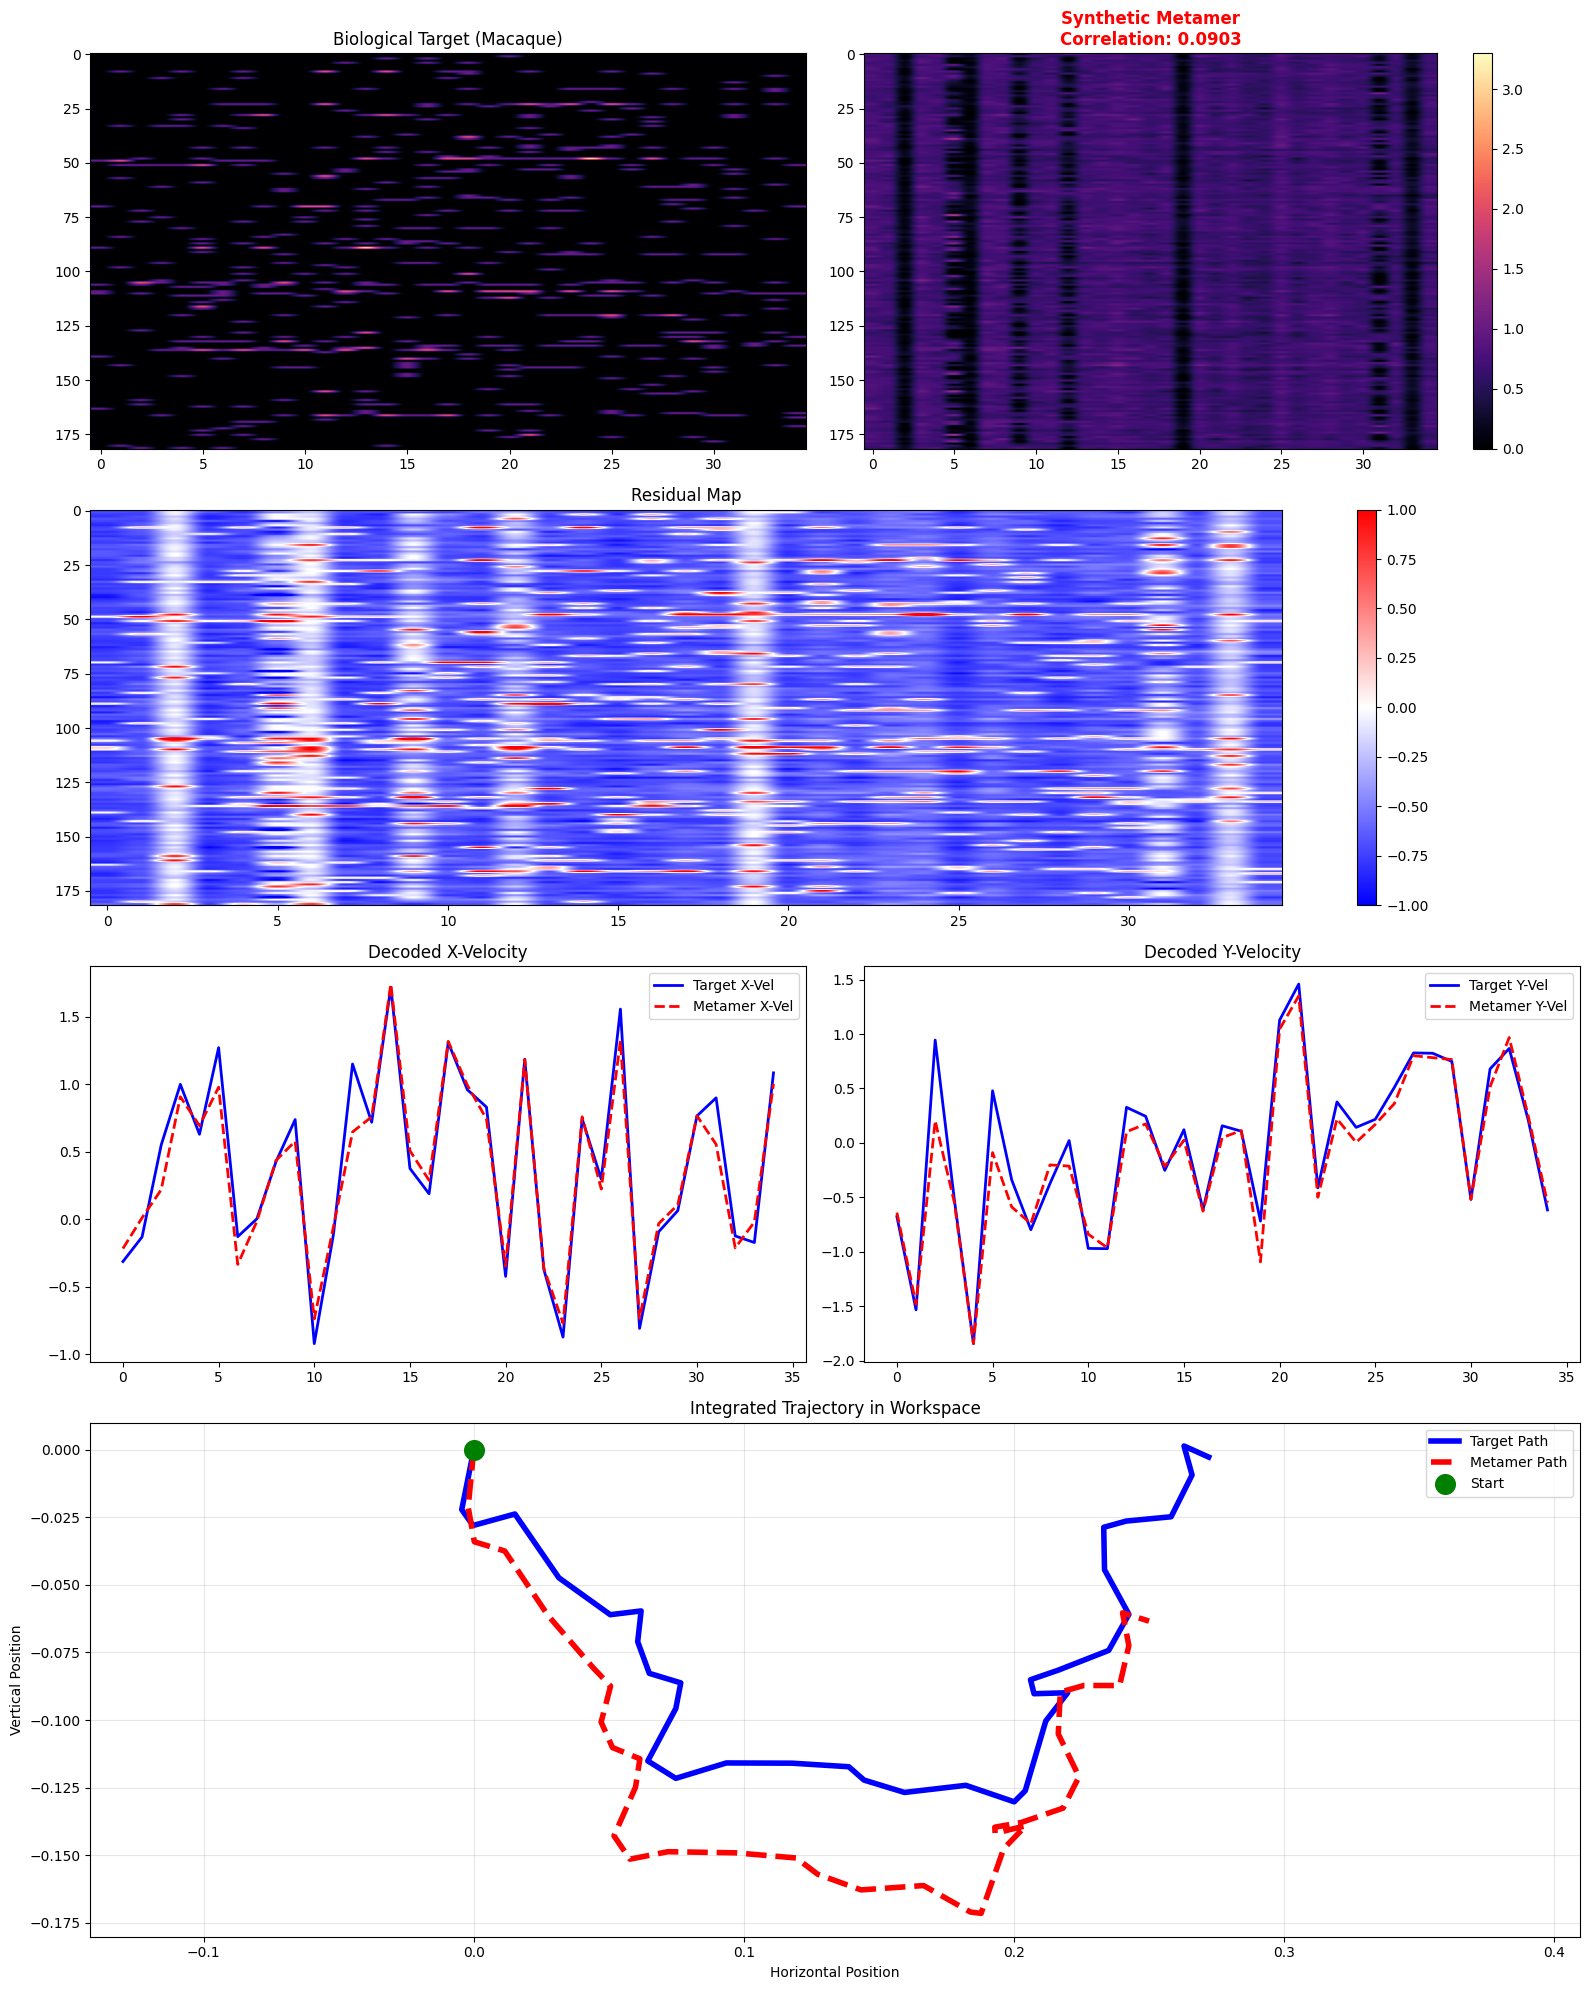

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cumtrapz
from scipy.stats import pearsonr

def plot_metamer_report(target_spikes, metamer_spikes, target_output, metamer_output):
    # 1. Kinematic Integration
    dt = 0.02 
    target_pos = cumtrapz(target_output, dx=dt, axis=0, initial=0)
    metamer_pos = cumtrapz(metamer_output, dx=dt, axis=0, initial=0)
    
    # 2. Correlation Analysis
    orig_flat = target_spikes[0].cpu().numpy().flatten()
    meta_flat = metamer_spikes[0].cpu().numpy().flatten()
    corr, _ = pearsonr(orig_flat, meta_flat)
    
    # 3. Determine the "Nature" of the Metamer
    if corr > 0.7:
        verdict = "DISTILLATION (Natural Denoising)"
        verdict_color = "green"
    elif corr < 0.3:
        verdict = "ADVERSARIAL (Artificial Hallucination)"
        verdict_color = "red"
    else:
        verdict = "MIXED (Partial Feature Match)"
        verdict_color = "orange"

    # 4. Figure Setup
    fig = plt.figure(figsize=(16, 20))
    gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1.3])

    # --- ROW 1: Inputs ---
    vmin, vmax = 0, max(target_spikes.max().item(), metamer_spikes.max().item()) * 1.1
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(target_spikes[0].cpu().T, aspect='auto', cmap='magma', vmin=vmin, vmax=vmax)
    ax0.set_title("Biological Target (Macaque)")
    
    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.imshow(metamer_spikes[0].cpu().T, aspect='auto', cmap='magma', vmin=vmin, vmax=vmax)
    ax1.set_title(f"Synthetic Metamer\nCorrelation: {corr:.4f}", color=verdict_color, fontweight='bold')
    plt.colorbar(im1, ax=ax1)

    # --- ROW 2: Residual Map ---
    ax2 = fig.add_subplot(gs[1, :])
    residual = (target_spikes[0] - metamer_spikes[0]).cpu().numpy().T
    im2 = ax2.imshow(residual, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
    ax2.set_title(f"Residual Map")
    plt.colorbar(im2, ax=ax2)

    # --- ROW 3: Behavioral Overlap ---
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.plot(target_output[:, 0], 'b', lw=2, label='Target X-Vel')
    ax3.plot(metamer_output[:, 0], 'r--', lw=2, label='Metamer X-Vel')
    ax3.set_title("Decoded X-Velocity")
    ax3.legend()

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.plot(target_output[:, 1], 'b', lw=2, label='Target Y-Vel')
    ax4.plot(metamer_output[:, 1], 'r--', lw=2, label='Metamer Y-Vel')
    ax4.set_title("Decoded Y-Velocity")
    ax4.legend()

    # --- ROW 4: Physical Trajectory (Restored Aspect Ratio) ---
    position_mse = np.mean((target_pos - metamer_pos) ** 2)
    
    print(f"Average Positional Error: {position_mse:.3f} units")
    ax5 = fig.add_subplot(gs[3, :])
    ax5.plot(target_pos[:, 0], target_pos[:, 1], 'b-', lw=4, label='Target Path')
    ax5.plot(metamer_pos[:, 0], metamer_pos[:, 1], 'r--', lw=4, label='Metamer Path')
    ax5.scatter(0, 0, color='green', s=200, label='Start', zorder=5)
    
    ax5.set_aspect('equal', adjustable='datalim') 
    
    ax5.set_title("Integrated Trajectory in Workspace")
    ax5.set_xlabel("Horizontal Position")
    ax5.set_ylabel("Vertical Position")
    ax5.grid(True, alpha=0.3)
    ax5.legend()

    plt.tight_layout()
    plt.show()

# Execution
with torch.no_grad():
    target_out = adapted_decoder(target_spike_train)[0].cpu().numpy()
    metamer_out = adapted_decoder(optimized_metamer)[0].cpu().numpy()

plot_metamer_report(target_spike_train, optimized_metamer, target_out, metamer_out)

In [115]:
from sklearn.cross_decomposition import CCA

def cca_latent_similarity(target_spikes, metamer_spikes):
    # Shape should be (Time, Neurons)
    # We add .detach() to safely pull it off the autograd graph
    X = target_spikes[0].detach().cpu().numpy().T 
    Y = metamer_spikes[0].detach().cpu().numpy().T
    
    # We look for the top 3 underlying latent factors
    cca = CCA(n_components=3)
    cca.fit(X, Y)
    
    # Transform both signals into their shared latent space
    X_c, Y_c = cca.transform(X, Y)
    
    # Calculate how perfectly these underlying spaces align
    corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(3)]
    
    print(f"CCA Dimension 1 (Primary Intent Alignment): {corrs[0]:.4f}")
    print(f"CCA Dimension 2 (Secondary Intent Alignment): {corrs[1]:.4f}")
    print(f"CCA Dimension 3 (Tertiary Intent Alignment): {corrs[2]:.4f}")
    
    return corrs

# Run the test
cca_latent_similarity(target_spike_train, optimized_metamer);

CCA Dimension 1 (Primary Intent Alignment): 0.8544
CCA Dimension 2 (Secondary Intent Alignment): 0.8318
CCA Dimension 3 (Tertiary Intent Alignment): 0.8178


## 7. Metamer Families

In [130]:
num_targets = 4
target_indices = [10, 20, 30, 40]

metamers = []

In [143]:
num_members = 100
metamer_optimizer = MetamerOptimizer(
    extractor=multi_extractor,
    target_features=target_multi_features,
    lr=0.02,
    max_iterations=250, 
    custom_loss_hook=adversarial_loss_hook,
    projection_fn=biological_projection,
)


trial_idx = 42
target_spike_train = real_spikes[trial_idx:trial_idx+1].to(device)

for j in range(num_members):
    print(f"Generating Metamer {j+1}")
    start = torch.randn_like(target_spike_train).abs() * 0.5
    optimized_metamer = metamer_optimizer.generate(starting_image=start)
    metamers.append(optimized_metamer)

print(f"We have {len(metamers)} metamers.")

Generating Metamer 1


Optimizing (mse): 100%|██████████| 250/250 [00:03<00:00, 63.67it/s, loss=0.192228]


Generating Metamer 2


Optimizing (mse): 100%|██████████| 250/250 [00:03<00:00, 62.97it/s, loss=0.188183]


Generating Metamer 3


...

Generating Metamer 99


Optimizing (mse): 100%|██████████| 250/250 [00:05<00:00, 45.97it/s, loss=0.189923]


Generating Metamer 100


Optimizing (mse): 100%|██████████| 250/250 [00:05<00:00, 46.27it/s, loss=0.191378]

We have 155 metamers.


Average Positional Error: 0.001 units


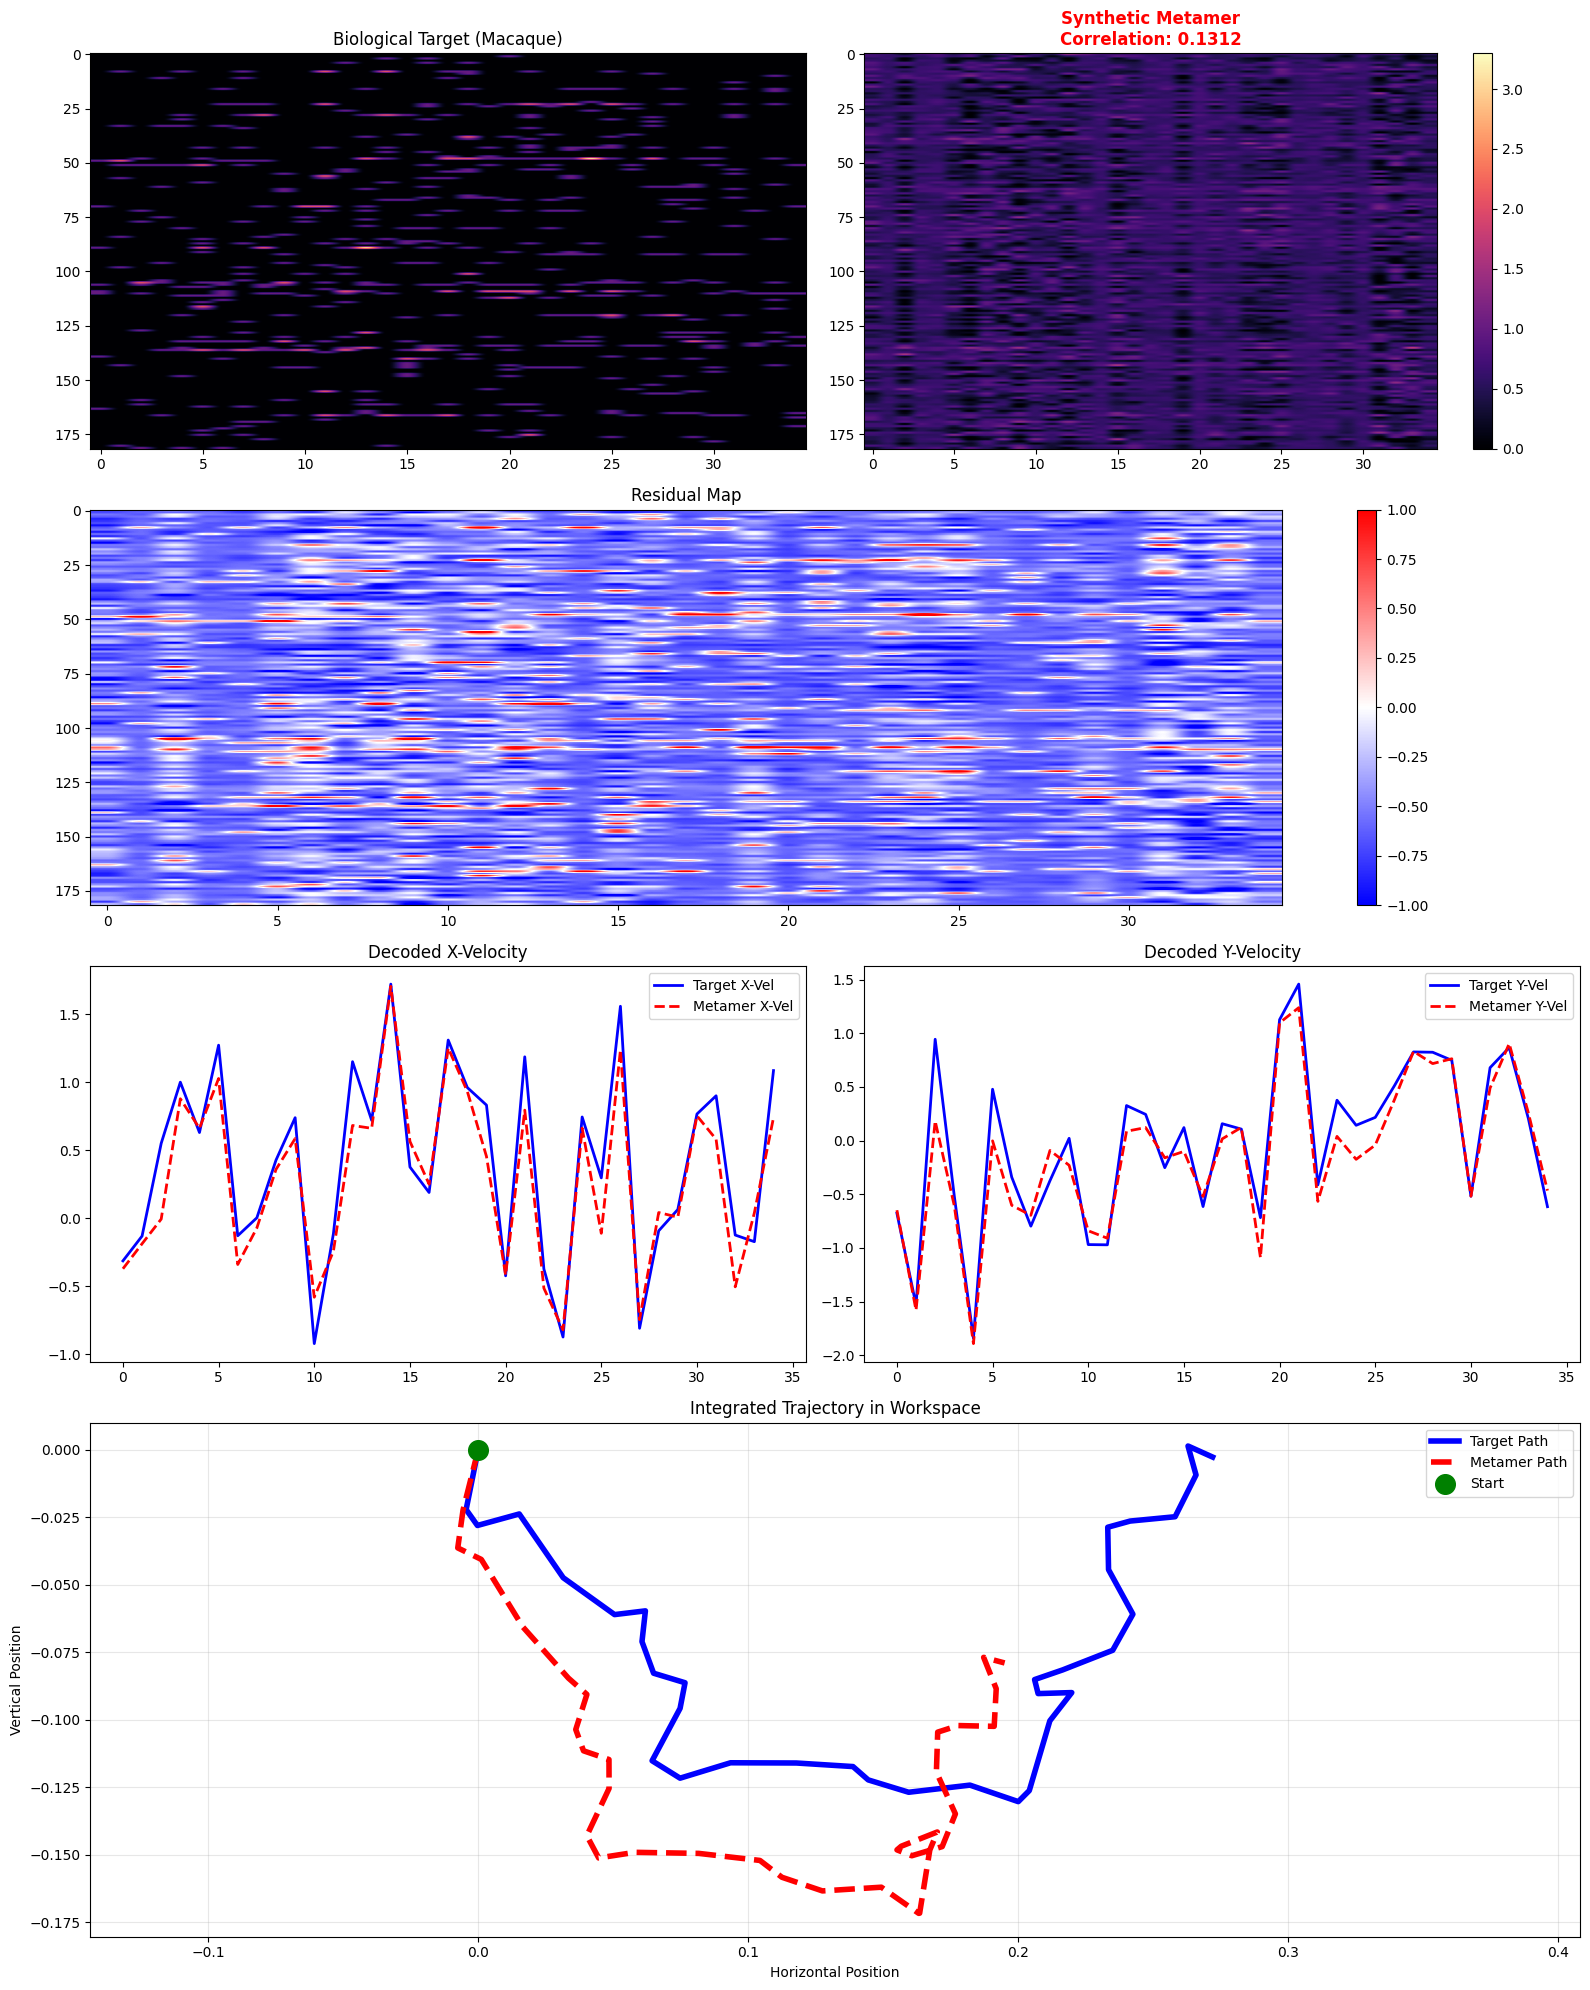

In [146]:
# Get average over metamers
average_metamer = torch.stack(metamers, dim=0).mean(dim=0)
# Execution
with torch.no_grad():
    target_out = adapted_decoder(target_spike_train)[0].cpu().numpy()
    metamer_out = adapted_decoder(average_metamer)[0].cpu().numpy()
    
plot_metamer_report(target_spike_train, average_metamer, target_out, metamer_out)

PCA Explained Variance Ratios: [0.108886   0.06504776]


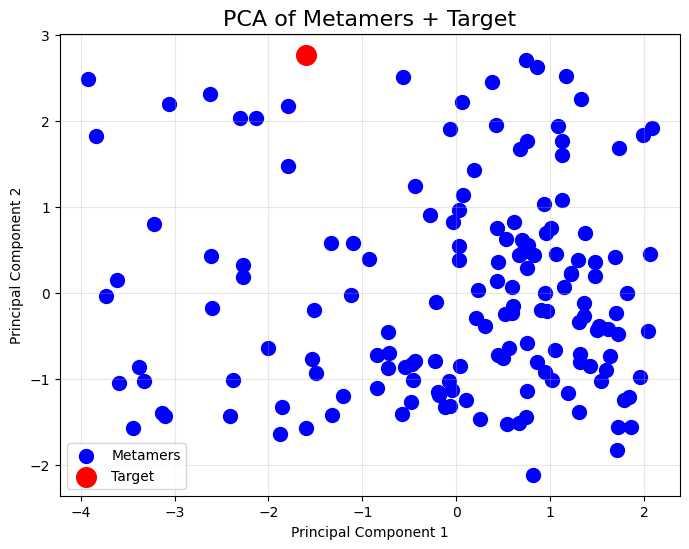

In [148]:
from sklearn.decomposition import PCA

metamer_matrix = torch.stack(metamers, dim=0).squeeze(1).cpu().numpy()
num_members, time_steps, num_neurons = metamer_matrix.shape
metamer_matrix_reshaped = metamer_matrix.reshape(num_members, -1)

pca = PCA(n_components=2)
pca.fit(metamer_matrix_reshaped)

print("PCA Explained Variance Ratios:", pca.explained_variance_ratio_)

metamer_pca = pca.transform(metamer_matrix_reshaped)

target_vec = target_spike_train.squeeze(0).detach().cpu().numpy()
target_vec = target_vec.reshape(1, -1)

target_pca = pca.transform(target_vec)

plt.figure(figsize=(8, 6))

# metamers
plt.scatter(metamer_pca[:, 0],metamer_pca[:, 1],c='blue',s=100,label='Metamers')

# target
plt.scatter(target_pca[:, 0],target_pca[:, 1],c='red',s=200,label='Target',)

plt.title("PCA of Metamers + Target", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()